In [48]:
# Cell 0
# CONFIG (edit these only)
import os
from pathlib import Path

# Root folder that contains the Visium dataset folders shown in Finder (rep1/rep2/rep3/rep4, day0, etc.)
DATA_ROOT = Path("/Users/yaelheyman/Library/CloudStorage/GoogleDrive-yaelhei@gmail.com/My Drive/SPRINKLING/SG/mouse visium data/versi data set")

# Folder that contains the raw 10x-style outputs (GSM... files)
RAW_DIR = DATA_ROOT / "GSE303705_RAW"

# What to analyze
REP = "rep2"          # "rep1", "rep2", "rep3", "rep4"
TIMEPOINT = "day0"    # "day0", "dayX", etc.

# Inflation settings
N_ITER = 20

DRAW_NEW_BORDERS = False  # set True only when drawing new luminal/basal polygons
SHOW_NAPARI_QC   = False  # set True to open Napari for mask QC
DRAW_NEW_SUBROI  = False  # set True only when drawing a new sub-ROI polygon  # set True only when drawing a new sub-ROI polygon
KERNEL_SIZE = 20

# ---- derived paths (usually no need to edit) ----
ROI_DIR = DATA_ROOT / REP / TIMEPOINT

# Napari polygon export CSV (axis-0/axis-1). Update naming rule if you use a different convention.
POLYGON_CSV       = ROI_DIR / f"{REP}_{TIMEPOINT}.csv"
BASAL_POLYGON_CSV = ROI_DIR / f"{REP}_{TIMEPOINT}_basal.csv"  # napari CSV for the outer (basal) border

GSM_BY_REP = {
    "rep1": "GSM9134407",
    "rep2": "GSM9134408",
    "rep3": "GSM9134409",
    "rep4": "GSM9134410",
}
SAMPLE_PREFIX = f"{GSM_BY_REP[REP]}_{REP}"

# Prefer unzipped files; if you still have .gz, unzip them or adjust these paths accordingly.
TISSUE_POSITIONS = RAW_DIR / f"{SAMPLE_PREFIX}_tissue_positions.parquet"
SCALEFACTORS_JSON = RAW_DIR / f"{SAMPLE_PREFIX}_scalefactors_json.json"
HIRES_IMAGE = RAW_DIR / f"{SAMPLE_PREFIX}_tissue_hires_image.png"

MATRIX_MTX = RAW_DIR / f"{SAMPLE_PREFIX}_matrix.mtx"
BARCODES_TSV = RAW_DIR / f"{SAMPLE_PREFIX}_barcodes.tsv"
FEATURES_TSV = RAW_DIR / f"{SAMPLE_PREFIX}_features.tsv"

# Output folders
OUT_BASE = ROI_DIR / "infl_out"
ITER_DIR = OUT_BASE / f"inflation_num_iterations_{N_ITER}"

print("ROI_DIR:", ROI_DIR)
print("HIRES_IMAGE:", HIRES_IMAGE)
print("ITER_DIR:", ITER_DIR)


ROI_DIR: /Users/yaelheyman/Library/CloudStorage/GoogleDrive-yaelhei@gmail.com/My Drive/SPRINKLING/SG/mouse visium data/versi data set/rep2/day0
HIRES_IMAGE: /Users/yaelheyman/Library/CloudStorage/GoogleDrive-yaelhei@gmail.com/My Drive/SPRINKLING/SG/mouse visium data/versi data set/GSE303705_RAW/GSM9134408_rep2_tissue_hires_image.png
ITER_DIR: /Users/yaelheyman/Library/CloudStorage/GoogleDrive-yaelhei@gmail.com/My Drive/SPRINKLING/SG/mouse visium data/versi data set/rep2/day0/infl_out/inflation_num_iterations_20


In [49]:
# Cell 1
if not DRAW_NEW_BORDERS:
    print('Skipping border drawing (DRAW_NEW_BORDERS=False)')
else:
    #use this cell to capture the desired mask in napari
    import napari
    import imageio.v3 as iio
    
    img = iio.imread(
        HIRES_IMAGE # <-- update path
    )
    
    viewer = napari.Viewer()
    viewer.add_image(img, name="tissue", contrast_limits=[img.min(), img.max()])
    napari.run()
    


Skipping border drawing (DRAW_NEW_BORDERS=False)


In [50]:
# Cell 2
import numpy as np
import cv2

def poly2mask_from_image_shape(vertices_xy, H, W, value=255):
    """
    vertices_xy: (N,2) in (x,y) = (col,row) pixel coords.
    Returns uint8 mask shape (H,W), values 0 or `value`.
    """
    v = np.asarray(vertices_xy, dtype=float)
    if v.ndim != 2 or v.shape[1] != 2:
        raise ValueError("vertices_xy must be (N,2) = (x,y)")

    x = np.clip(np.round(v[:, 0]), 0, W - 1)
    y = np.clip(np.round(v[:, 1]), 0, H - 1)

    pts = np.stack([x, y], axis=1).astype(np.int32).reshape((-1, 1, 2))
    mask = np.zeros((H, W), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], color=int(value))
    return mask


In [51]:
# Cell 3
import pandas as pd
import imageio.v3 as iio

# Load tissue image and create masks from polygon CSVs (always runs)
img = iio.imread(str(HIRES_IMAGE))
H, W = img.shape[:2]

df_poly = pd.read_csv(POLYGON_CSV)
vertices_xy = df_poly[['axis-1', 'axis-0']].to_numpy()
mask = poly2mask_from_image_shape(vertices_xy, H, W, value=255)

df_basal = pd.read_csv(BASAL_POLYGON_CSV)
vertices_basal_xy = df_basal[['axis-1', 'axis-0']].to_numpy()
basal_mask = poly2mask_from_image_shape(vertices_basal_xy, H, W, value=255)

print(f'Luminal mask: {mask.shape}, nonzero pixels: {(mask>0).sum():,}')
print(f'Basal mask:   {basal_mask.shape}, nonzero pixels: {(basal_mask>0).sum():,}')

# Optional: open Napari for visual QC
if SHOW_NAPARI_QC:
    %gui qt
    import napari
    viewer = napari.Viewer()
    viewer.add_image(img, name='image')
    viewer.add_image(mask, name='mask', contrast_limits=[0,255], colormap='red', blending='additive')
    viewer.add_image(basal_mask, name='basal_mask', contrast_limits=[0,255], colormap='cyan', blending='additive')
else:
    print('Napari QC skipped (SHOW_NAPARI_QC=False)')


Luminal mask: (6000, 5933), nonzero pixels: 657,696
Basal mask:   (6000, 5933), nonzero pixels: 2,148,244
Napari QC skipped (SHOW_NAPARI_QC=False)


In [52]:
# Cell 4
import os
from inflation_analysis_v2 import InflationAnalysis

ia = InflationAnalysis(output_folder=os.path.join(str(ROI_DIR), 'infl_out'),
                       kernel_size=KERNEL_SIZE,
                       inflation_iterations=N_ITER,
                       pixel2nm=1)
ia.set_mask(mask)              # luminal (inner) polygon mask
ia.set_basal_mask(basal_mask)  # basal (outer) polygon mask — clips dilation

# Save border overlay immediately (before analysis, so it's always produced)
ia.save_border_overlay(
    tissue_img=img,
    output_path=os.path.join(str(ROI_DIR), "infl_out", "border_overlay.png")
)

ia.inflate_and_save()

# average section thickness is printed above and saved to section_thickness.csv


Border overlay saved: /Users/yaelheyman/Library/CloudStorage/GoogleDrive-yaelhei@gmail.com/My Drive/SPRINKLING/SG/mouse visium data/versi data set/rep2/day0/infl_out/border_overlay.png
Inflation iteration 1
Inflation iteration 2
Inflation iteration 3
Inflation iteration 4
Inflation iteration 5
Inflation iteration 6
Inflation iteration 7
Inflation iteration 8
Inflation iteration 9
Inflation iteration 10
Inflation iteration 11
Inflation iteration 12
Inflation iteration 13
Inflation iteration 14
Inflation iteration 15
Inflation iteration 16
Inflation iteration 17
Inflation iteration 18
  → all ROI pixels assigned, stopping.

Average section thickness: 0.14 µm  (18 rings)


/Users/YaelHeyman/Documents/GitHub/monolayer_analysis/inflation_analysis_v2.py:325: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


In [53]:
# Cell 5
# Local width distribution along the tissue section
# Solution 1: set min_width_um to exclude the cut area (near-zero width points)
# Solution 2: set min_width_um=None to include all points and see the full distribution

MIN_WIDTH_UM = 50   # µm — points below this are treated as cut tissue and excluded
                    # set to None to disable filtering

width_df, width_stats = ia.compute_local_widths(
    n_samples=500,
    min_width_um=MIN_WIDTH_UM,
    save_csv=True,
    iter_dir=str(ITER_DIR),
)

ia.save_width_profile_overlay(
    tissue_img=img,
    width_df=width_df,
    output_path=str(ITER_DIR / 'width_profile_overlay.png'),
    n_lines=300,
)

print(width_stats)

Width profile overlay saved: /Users/yaelheyman/Library/CloudStorage/GoogleDrive-yaelhei@gmail.com/My Drive/SPRINKLING/SG/mouse visium data/versi data set/rep2/day0/infl_out/inflation_num_iterations_20/width_profile_overlay.png
{'mean_um': 0.14927329362363911, 'std_um': 0.03022487898581203, 'median_um': 0.151, 'n_total': 500, 'n_included': 479}


In [54]:
# Cell 6
if not DRAW_NEW_SUBROI:
    print('Skipping sub-ROI drawing (DRAW_NEW_SUBROI=False)')
else:
    # ── Sub-ROI selection in Napari ──────────────────────────────────────────────
    # Open Napari showing the hires tissue image + border overlay.
    # Draw a SINGLE polygon around the region you want to keep, then run the
    # next cell to save it.
    #
    # Controls: polygon tool is activated automatically.
    #   - Click to add vertices.  Double-click to close the polygon.
    #   - To redo: delete the shape and draw again.
    # ─────────────────────────────────────────────────────────────────────────────
    %gui qt
    import napari
    import imageio.v3 as iio
    import os
    
    img = iio.imread(str(HIRES_IMAGE))
    
    viewer = napari.Viewer()
    viewer.add_image(img, name='tissue')
    
    # Show border overlay as a reference layer (if it exists)
    border_path = str(OUT_BASE / 'border_overlay.png')
    if os.path.exists(border_path):
        border_img = iio.imread(border_path)
        viewer.add_image(border_img, name='border_overlay', opacity=0.7)
    
    # Shapes layer for drawing the sub-ROI
    subroi_shapes = viewer.add_shapes(
        name='sub_roi',
        shape_type='polygon',
        edge_color='yellow',
        face_color=[1, 1, 0, 0.15],
        edge_width=3,
    )
    viewer.layers.selection.active = subroi_shapes
    subroi_shapes.mode = 'add_polygon'
    
    print('Draw your sub-ROI polygon on the tissue, then run the next cell to save it.')
    


Skipping sub-ROI drawing (DRAW_NEW_SUBROI=False)


In [55]:
# Cell 7
if not DRAW_NEW_SUBROI:
    print('Skipping sub-ROI save (DRAW_NEW_SUBROI=False)')
else:
    # ── Save sub-ROI polygon ──────────────────────────────────────────────────────
    import pandas as pd
    
    SUBROI_POLYGON_CSV = ROI_DIR / f'{REP}_{TIMEPOINT}_subroi.csv'
    
    shapes_layer = viewer.layers['sub_roi']
    if len(shapes_layer.data) == 0:
        print('No polygon drawn yet — draw one in Napari first.')
    else:
        poly = shapes_layer.data[0]  # (N, 2) in (axis-0=y, axis-1=x) format
        df_subroi = pd.DataFrame({'axis-0': poly[:, 0], 'axis-1': poly[:, 1]})
        df_subroi.to_csv(SUBROI_POLYGON_CSV, index=False)
        print(f'Saved sub-ROI polygon ({len(poly)} vertices): {SUBROI_POLYGON_CSV}')
    


Skipping sub-ROI save (DRAW_NEW_SUBROI=False)


In [56]:
# Cell 8
# ── Re-run ring/gene-matrix subset for sub-ROI ────────────────────────────────
# Reads the sub-ROI polygon, filters bins to those inside it, and saves:
#   {ITER_DIR}/ring_subset_bin_by_gene_subroi/
# The original ring_subset_bin_by_gene/ folder is NOT touched.
# ─────────────────────────────────────────────────────────────────────────────
import os, json
import numpy as np
import pandas as pd
import scipy.sparse as sp
import imageio.v3 as iio

# ── Helper functions (also defined in Cells 10/11) ───────────────────────────
def poly2mask_from_image_shape(vertices_xy, H, W, value=255):
    """
    vertices_xy: (N,2) in (x,y) = (col,row) pixel coords.
    Returns uint8 mask shape (H,W), values 0 or `value`.
    """
    v = np.asarray(vertices_xy, dtype=float)
    if v.ndim != 2 or v.shape[1] != 2:
        raise ValueError("vertices_xy must be (N,2) = (x,y)")

    x = np.clip(np.round(v[:, 0]), 0, W - 1)
    y = np.clip(np.round(v[:, 1]), 0, H - 1)

    pts = np.stack([x, y], axis=1).astype(np.int32).reshape((-1, 1, 2))
    mask = np.zeros((H, W), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], color=int(value))
    return mask

def load_scalefactors_json(path_scalefactors_json):
    with open(path_scalefactors_json, "r") as f:
        return json.load(f)

def load_tissue_positions_parquet(path_parquet):
    return pd.read_parquet(path_parquet)

def get_xy_from_positions(df, scalefactors, target="hires"):
    if "barcode" not in df.columns:
        raise KeyError("Expected a 'barcode' column in tissue_positions parquet.")

    if "in_tissue" in df.columns:
        df = df[df["in_tissue"].astype(int) == 1].copy()

    needed = {"pxl_row_in_fullres", "pxl_col_in_fullres"}
    if not needed.issubset(df.columns):
        raise KeyError(f"Expected columns {needed} in tissue_positions parquet. Found: {list(df.columns)}")

    y_full = df["pxl_row_in_fullres"].to_numpy()
    x_full = df["pxl_col_in_fullres"].to_numpy()

    if target == "hires":
        s = float(scalefactors["tissue_hires_scalef"])
        x = x_full * s
        y = y_full * s
    elif target == "fullres":
        x, y = x_full, y_full
    else:
        raise ValueError("target must be 'hires' or 'fullres'")

    return pd.DataFrame({
        "barcode": df["barcode"].astype(str).to_numpy(),
        "x": x,
        "y": y,
    })

def load_barcodes_tsv(barcodes_tsv):
    return pd.read_csv(barcodes_tsv, header=None, sep="\t")[0].astype(str).tolist()

def load_features_tsv(features_tsv):
    df = pd.read_csv(features_tsv, header=None, sep="\t")
    if df.shape[1] == 1:
        df.columns = ["feature_id"]
        df["feature_name"] = df["feature_id"]
    else:
        df.columns = ["feature_id", "feature_name"] + [f"col{i}" for i in range(2, df.shape[1])]
    return df

def subset_mtx_by_barcodes_stream(mtx_path, barcodes_tsv, features_tsv, selected_barcodes):
    all_barcodes = load_barcodes_tsv(barcodes_tsv)
    features_df = load_features_tsv(features_tsv)

    bc_to_col = {bc: j for j, bc in enumerate(all_barcodes)}

    selected = [bc for bc in selected_barcodes if bc in bc_to_col]
    if not selected:
        raise ValueError("None of the selected barcodes were found in barcodes.tsv")

    old_cols = np.array([bc_to_col[bc] for bc in selected], dtype=np.int64)
    old_to_new = {int(old): new for new, old in enumerate(old_cols)}
    keep_cols = set(old_to_new.keys())

    rows = []
    cols = []
    data = []

    with open(mtx_path, "r") as f:
        line = f.readline()
        while line.startswith("%"):
            line = f.readline()

        nrows, ncols, nnz = map(int, line.strip().split())

        for ln in f:
            if not ln.strip():
                continue
            r, c, v = ln.split()
            r = int(r) - 1
            c = int(c) - 1
            if c in keep_cols:
                rows.append(r)
                cols.append(old_to_new[c])
                data.append(float(v))

    X_sub = sp.coo_matrix((data, (rows, cols)), shape=(nrows, len(selected))).tocsr()
    return X_sub, selected, features_df

def save_bin_by_gene_outputs(out_dir, X_genes_by_bins, barcodes, features_df, barcode_to_ring_df=None):
    os.makedirs(out_dir, exist_ok=True)

    sp.save_npz(os.path.join(out_dir, "counts_genes_by_bins.npz"), X_genes_by_bins)
    pd.Series(barcodes).to_csv(os.path.join(out_dir, "barcodes.tsv"), sep="\t", index=False, header=False)
    features_df.to_csv(os.path.join(out_dir, "features.tsv"), sep="\t", index=False)

    if barcode_to_ring_df is not None:
        m = barcode_to_ring_df.set_index("barcode").reindex(barcodes).reset_index()
        m.to_csv(os.path.join(out_dir, "barcode_to_ring_aligned.csv"), index=False)

diff_dir = str(ITER_DIR)
barcode_to_ring_path = os.path.join(diff_dir, "barcode_to_ring.csv")
barcode_to_ring_df = pd.read_csv(barcode_to_ring_path)

# nice downstream: group columns by ring
selected_barcodes = barcode_to_ring_df.sort_values("ring")["barcode"].astype(str).tolist()

X_genes_by_bins, barcodes_selected_ordered, features_df = subset_mtx_by_barcodes_stream(
    mtx_path=str(MATRIX_MTX),
    barcodes_tsv=str(BARCODES_TSV),
    features_tsv=str(FEATURES_TSV),
    selected_barcodes=selected_barcodes,
)

print("Subset sparse matrix shape (genes x selected_bins):", X_genes_by_bins.shape)
print("Nonzeros:", X_genes_by_bins.nnz)

out_dir = os.path.join(diff_dir, "ring_subset_bin_by_gene")
save_bin_by_gene_outputs(out_dir, X_genes_by_bins, barcodes_selected_ordered, features_df, barcode_to_ring_df)
print("Wrote sparse outputs to:", out_dir)

# ─────────────────────────────────────────────────────────────────────────────
SUBROI_POLYGON_CSV = ROI_DIR / f'{REP}_{TIMEPOINT}_subroi.csv'
SUBROI_SUBSET_DIR  = str(ITER_DIR / 'ring_subset_bin_by_gene_subroi')

if not SUBROI_POLYGON_CSV.exists():
    print(f'No sub-ROI polygon found for {REP}/{TIMEPOINT} — skipping sub-ROI filter.')
    print(f'To create one: set DRAW_NEW_SUBROI=True and run Cells 6+7.')
else:
    
    # Load sub-ROI polygon → mask
    img = iio.imread(str(HIRES_IMAGE))
    H, W = img.shape[:2]
    df_subroi = pd.read_csv(SUBROI_POLYGON_CSV)
    vertices_xy = df_subroi[['axis-1', 'axis-0']].to_numpy()
    subroi_mask = poly2mask_from_image_shape(vertices_xy, H, W, value=1)
    
    # Load existing full ring assignment
    orig_ring_map = pd.read_csv(
        str(ITER_DIR / 'ring_subset_bin_by_gene' / 'barcode_to_ring_aligned.csv')
    )
    
    # Load bin hires-pixel positions
    scalefactors = load_scalefactors_json(str(SCALEFACTORS_JSON))
    pos_df       = load_tissue_positions_parquet(str(TISSUE_POSITIONS))
    xy_df        = get_xy_from_positions(pos_df, scalefactors, target='hires')
    
    # Merge positions into ring_map
    merged = orig_ring_map.merge(xy_df, on='barcode', how='left')
    
    # Keep only bins whose centre falls inside the sub-ROI mask
    xi = np.clip(merged['x'].to_numpy().astype(int), 0, W - 1)
    yi = np.clip(merged['y'].to_numpy().astype(int), 0, H - 1)
    in_subroi = subroi_mask[yi, xi] > 0
    filtered  = merged[in_subroi].copy()
    
    print(f'Original bins : {len(merged):,}')
    print(f'Sub-ROI bins  : {len(filtered):,}  ({100*in_subroi.mean():.1f}% retained)')
    print(f'Ring distribution after filtering:')
    print(filtered['ring'].value_counts().sort_index().to_string())
    
    # Save filtered ring map
    os.makedirs(SUBROI_SUBSET_DIR, exist_ok=True)
    filtered[['barcode', 'ring']].to_csv(
        os.path.join(SUBROI_SUBSET_DIR, 'barcode_to_ring_aligned.csv'), index=False
    )
    
    # Rebuild gene expression matrix for the filtered barcodes
    selected_barcodes = filtered['barcode'].tolist()
    X_sub, selected_bcs, features_df = subset_mtx_by_barcodes_stream(
        str(MATRIX_MTX), str(BARCODES_TSV), str(FEATURES_TSV), selected_barcodes
    )
    save_bin_by_gene_outputs(SUBROI_SUBSET_DIR, X_sub, selected_bcs, features_df)
    
    print(f'\nSaved to: {SUBROI_SUBSET_DIR}')
    

Subset sparse matrix shape (genes x selected_bins): (19059, 75034)
Nonzeros: 56669409
Wrote sparse outputs to: /Users/yaelheyman/Library/CloudStorage/GoogleDrive-yaelhei@gmail.com/My Drive/SPRINKLING/SG/mouse visium data/versi data set/rep2/day0/infl_out/inflation_num_iterations_20/ring_subset_bin_by_gene
Original bins : 75,034
Sub-ROI bins  : 32,365  (43.1% retained)
Ring distribution after filtering:
ring
1     1423
2     1823
3     2058
4     2182
5     2294
6     2371
7     2438
8     2516
9     2557
10    2594
11    2427
12    2276
13    1899
14    1497
15    1110
16     624
17     240
18      36

Saved to: /Users/yaelheyman/Library/CloudStorage/GoogleDrive-yaelhei@gmail.com/My Drive/SPRINKLING/SG/mouse visium data/versi data set/rep2/day0/infl_out/inflation_num_iterations_20/ring_subset_bin_by_gene_subroi


/var/folders/9s/w3bt4kcj07g4qkxb1ckgxhs00000gt/T/ipykernel_73570/3061459839.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(diff_paths))


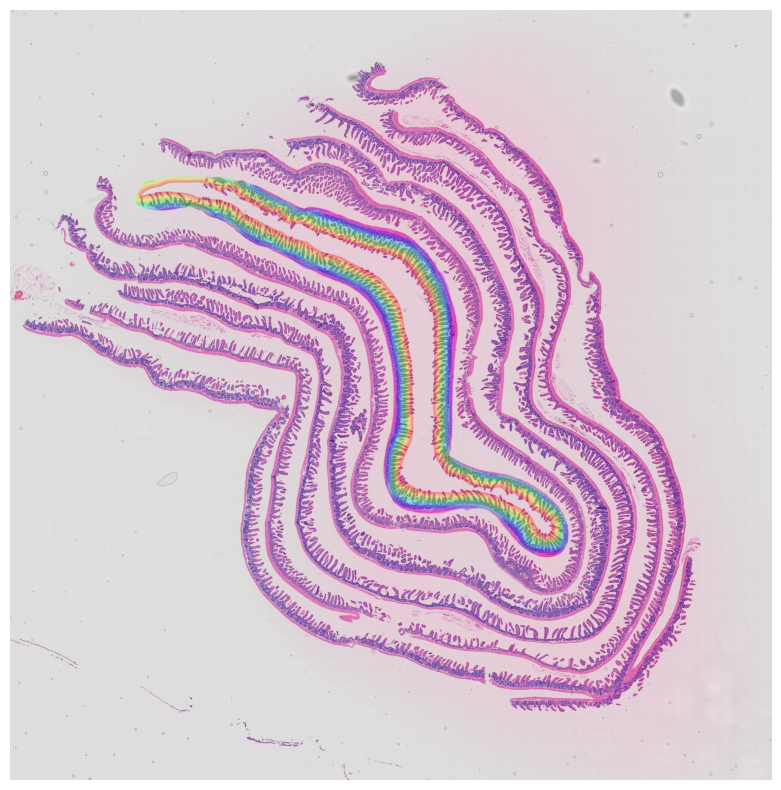

In [57]:
# Cell 9
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib import cm

def _natural_key(path):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", os.path.basename(path))]

def overlay_diff_masks_rainbow(
    diff_dir,
    diff_glob="inflated_diff_*.png",
    base_img=None,          # ndarray (H,W) or (H,W,3)
    alpha=0.35,
    cmap_name="hsv",
    show=True,
):
    diff_paths = sorted(glob.glob(os.path.join(diff_dir, diff_glob)), key=_natural_key)
    if len(diff_paths) == 0:
        raise FileNotFoundError(f"No diff masks found with {os.path.join(diff_dir, diff_glob)}")

    # Load first diff to get shape
    first = np.array(Image.open(diff_paths[0]))
    if first.ndim == 3:
        first = first[..., 0]
    H, W = first.shape[:2]

    # Base image -> RGB float in [0,1]
    if base_img is None:
        comp = np.zeros((H, W, 3), dtype=np.float32)
    else:
        b = np.asarray(base_img)
        if b.shape[0] != H or b.shape[1] != W:
            raise ValueError(f"base_img shape {b.shape[:2]} does not match diff shape {(H,W)}")

        if b.ndim == 2:
            b = b.astype(np.float32)
            b = (b - b.min()) / (b.max() - b.min() + 1e-8)
            comp = np.repeat(b[..., None], 3, axis=2)
        elif b.ndim == 3 and b.shape[2] in (3, 4):
            b = b[..., :3].astype(np.float32)
            if b.max() > 1.5:
                b /= 255.0
            comp = np.clip(b, 0, 1)
        else:
            raise ValueError("base_img must be (H,W), (H,W,3), or (H,W,4)")

    cmap = cm.get_cmap(cmap_name, len(diff_paths))

    for i, p in enumerate(diff_paths):
        diff = np.array(Image.open(p))
        if diff.ndim == 3:
            diff = diff[..., 0]
        m = diff > 0

        color = np.array(cmap(i)[:3], dtype=np.float32)
        comp[m] = (1 - alpha) * comp[m] + alpha * color

    comp = np.clip(comp, 0, 1)

    if show:
        plt.figure(figsize=(8, 8))
        plt.imshow(comp)
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    return comp

# Example overlay QC (image + all diff masks rainbow)
diff_dir = str(ITER_DIR)
comp = overlay_diff_masks_rainbow(diff_dir, base_img=img, alpha=0.35, cmap_name="hsv")


In [58]:
# Cell 10
# STEP 1: Map Visium barcodes (bins/spots) to inflation diff-ring index using diff masks + tissue_positions + scalefactors
import os, glob, re, json
import numpy as np
import pandas as pd
from PIL import Image

def natural_sort(paths):
    def key(s):
        return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", os.path.basename(s))]
    return sorted(paths, key=key)

def load_scalefactors_json(path_scalefactors_json):
    with open(path_scalefactors_json, "r") as f:
        return json.load(f)

def load_tissue_positions_parquet(path_parquet):
    return pd.read_parquet(path_parquet)

def get_xy_from_positions(df, scalefactors, target="hires"):
    if "barcode" not in df.columns:
        raise KeyError("Expected a 'barcode' column in tissue_positions parquet.")

    if "in_tissue" in df.columns:
        df = df[df["in_tissue"].astype(int) == 1].copy()

    needed = {"pxl_row_in_fullres", "pxl_col_in_fullres"}
    if not needed.issubset(df.columns):
        raise KeyError(f"Expected columns {needed} in tissue_positions parquet. Found: {list(df.columns)}")

    y_full = df["pxl_row_in_fullres"].to_numpy()
    x_full = df["pxl_col_in_fullres"].to_numpy()

    if target == "hires":
        s = float(scalefactors["tissue_hires_scalef"])
        x = x_full * s
        y = y_full * s
    elif target == "fullres":
        x, y = x_full, y_full
    else:
        raise ValueError("target must be 'hires' or 'fullres'")

    return pd.DataFrame({
        "barcode": df["barcode"].astype(str).to_numpy(),
        "x": x,
        "y": y,
    })

def assign_rings_from_diff_masks(
    diff_dir,
    tissue_pos_parquet_path,
    scalefactors_json_path,
    diff_glob="inflated_diff_*.png",
    target="hires",
):
    diff_paths = natural_sort(glob.glob(os.path.join(diff_dir, diff_glob)))
    if not diff_paths:
        raise FileNotFoundError(f"No diff masks found in {diff_dir} matching {diff_glob}")

    first = np.array(Image.open(diff_paths[0]))
    if first.ndim == 3:
        first = first[..., 0]
    H, W = first.shape[:2]

    scalefactors = load_scalefactors_json(scalefactors_json_path)
    pos_df = load_tissue_positions_parquet(tissue_pos_parquet_path)
    xy = get_xy_from_positions(pos_df, scalefactors, target=target)

    xi = np.round(xy["x"].to_numpy()).astype(int)
    yi = np.round(xy["y"].to_numpy()).astype(int)

    inb = (xi >= 0) & (xi < W) & (yi >= 0) & (yi < H)
    xy = xy.loc[inb].reset_index(drop=True)
    xi = xi[inb]
    yi = yi[inb]

    barcodes = xy["barcode"].to_numpy()

    ring_to_barcodes = {}
    barcode_to_ring = {}

    for ring_idx, p in enumerate(diff_paths, start=1):
        diff = np.array(Image.open(p))
        if diff.ndim == 3:
            diff = diff[..., 0]
        m = diff > 0

        hits = m[yi, xi]
        ring_bcs = barcodes[hits]

        ring_to_barcodes[ring_idx] = ring_bcs.tolist()
        for bc in ring_bcs:
            if bc not in barcode_to_ring:
                barcode_to_ring[bc] = ring_idx

        print(f"Ring {ring_idx}: {len(ring_bcs)} bins")

    return ring_to_barcodes, barcode_to_ring

diff_dir = str(ITER_DIR)
ring_to_barcodes, barcode_to_ring = assign_rings_from_diff_masks(
    diff_dir=diff_dir,
    tissue_pos_parquet_path=str(TISSUE_POSITIONS),
    scalefactors_json_path=str(SCALEFACTORS_JSON),
    diff_glob="inflated_diff_*.png",
    target="hires",
)

print("Total unique bins assigned to any ring:", len(barcode_to_ring))

out_barcode_to_ring = os.path.join(diff_dir, "barcode_to_ring.csv")
pd.DataFrame({
    "barcode": list(barcode_to_ring.keys()),
    "ring": list(barcode_to_ring.values()),
}).to_csv(out_barcode_to_ring, index=False)
print("Wrote:", out_barcode_to_ring)

out_ring_to_barcodes = os.path.join(diff_dir, "ring_to_barcodes.csv")
pd.DataFrame(
    [(r, bc) for r, bcs in ring_to_barcodes.items() for bc in bcs],
    columns=["ring", "barcode"],
).to_csv(out_ring_to_barcodes, index=False)
print("Wrote:", out_ring_to_barcodes)


Ring 1: 3899 bins
Ring 2: 4852 bins
Ring 3: 5411 bins
Ring 4: 5608 bins
Ring 5: 5818 bins
Ring 6: 6040 bins
Ring 7: 6307 bins
Ring 8: 6458 bins
Ring 9: 6438 bins
Ring 10: 5879 bins
Ring 11: 4942 bins
Ring 12: 4245 bins
Ring 13: 3621 bins
Ring 14: 2711 bins
Ring 15: 1699 bins
Ring 16: 824 bins
Ring 17: 246 bins
Ring 18: 36 bins
Total unique bins assigned to any ring: 75034
Wrote: /Users/yaelheyman/Library/CloudStorage/GoogleDrive-yaelhei@gmail.com/My Drive/SPRINKLING/SG/mouse visium data/versi data set/rep2/day0/infl_out/inflation_num_iterations_20/barcode_to_ring.csv
Wrote: /Users/yaelheyman/Library/CloudStorage/GoogleDrive-yaelhei@gmail.com/My Drive/SPRINKLING/SG/mouse visium data/versi data set/rep2/day0/infl_out/inflation_num_iterations_20/ring_to_barcodes.csv


In [59]:
# Cell 11
# STEP 2: Build a (bins/spots) x (genes) table ONLY for barcodes that appear in your rings
# Assumes files are UNZIPPED: matrix.mtx, barcodes.tsv, features.tsv

import os
import numpy as np
import pandas as pd
import scipy.sparse as sp

def load_barcodes_tsv(barcodes_tsv):
    return pd.read_csv(barcodes_tsv, header=None, sep="\t")[0].astype(str).tolist()

def load_features_tsv(features_tsv):
    df = pd.read_csv(features_tsv, header=None, sep="\t")
    if df.shape[1] == 1:
        df.columns = ["feature_id"]
        df["feature_name"] = df["feature_id"]
    else:
        df.columns = ["feature_id", "feature_name"] + [f"col{i}" for i in range(2, df.shape[1])]
    return df

def subset_mtx_by_barcodes_stream(mtx_path, barcodes_tsv, features_tsv, selected_barcodes):
    all_barcodes = load_barcodes_tsv(barcodes_tsv)
    features_df = load_features_tsv(features_tsv)

    bc_to_col = {bc: j for j, bc in enumerate(all_barcodes)}

    selected = [bc for bc in selected_barcodes if bc in bc_to_col]
    if not selected:
        raise ValueError("None of the selected barcodes were found in barcodes.tsv")

    old_cols = np.array([bc_to_col[bc] for bc in selected], dtype=np.int64)
    old_to_new = {int(old): new for new, old in enumerate(old_cols)}
    keep_cols = set(old_to_new.keys())

    rows = []
    cols = []
    data = []

    with open(mtx_path, "r") as f:
        line = f.readline()
        while line.startswith("%"):
            line = f.readline()

        nrows, ncols, nnz = map(int, line.strip().split())

        for ln in f:
            if not ln.strip():
                continue
            r, c, v = ln.split()
            r = int(r) - 1
            c = int(c) - 1
            if c in keep_cols:
                rows.append(r)
                cols.append(old_to_new[c])
                data.append(float(v))

    X_sub = sp.coo_matrix((data, (rows, cols)), shape=(nrows, len(selected))).tocsr()
    return X_sub, selected, features_df

def save_bin_by_gene_outputs(out_dir, X_genes_by_bins, barcodes, features_df, barcode_to_ring_df=None):
    os.makedirs(out_dir, exist_ok=True)

    sp.save_npz(os.path.join(out_dir, "counts_genes_by_bins.npz"), X_genes_by_bins)
    pd.Series(barcodes).to_csv(os.path.join(out_dir, "barcodes.tsv"), sep="\t", index=False, header=False)
    features_df.to_csv(os.path.join(out_dir, "features.tsv"), sep="\t", index=False)

    if barcode_to_ring_df is not None:
        m = barcode_to_ring_df.set_index("barcode").reindex(barcodes).reset_index()
        m.to_csv(os.path.join(out_dir, "barcode_to_ring_aligned.csv"), index=False)

diff_dir = str(ITER_DIR)
barcode_to_ring_path = os.path.join(diff_dir, "barcode_to_ring.csv")
barcode_to_ring_df = pd.read_csv(barcode_to_ring_path)

# nice downstream: group columns by ring
selected_barcodes = barcode_to_ring_df.sort_values("ring")["barcode"].astype(str).tolist()

X_genes_by_bins, barcodes_selected_ordered, features_df = subset_mtx_by_barcodes_stream(
    mtx_path=str(MATRIX_MTX),
    barcodes_tsv=str(BARCODES_TSV),
    features_tsv=str(FEATURES_TSV),
    selected_barcodes=selected_barcodes,
)

print("Subset sparse matrix shape (genes x selected_bins):", X_genes_by_bins.shape)
print("Nonzeros:", X_genes_by_bins.nnz)

out_dir = os.path.join(diff_dir, "ring_subset_bin_by_gene")
save_bin_by_gene_outputs(out_dir, X_genes_by_bins, barcodes_selected_ordered, features_df, barcode_to_ring_df)
print("Wrote sparse outputs to:", out_dir)


Subset sparse matrix shape (genes x selected_bins): (19059, 75034)
Nonzeros: 56669409
Wrote sparse outputs to: /Users/yaelheyman/Library/CloudStorage/GoogleDrive-yaelhei@gmail.com/My Drive/SPRINKLING/SG/mouse visium data/versi data set/rep2/day0/infl_out/inflation_num_iterations_20/ring_subset_bin_by_gene


/var/folders/9s/w3bt4kcj07g4qkxb1ckgxhs00000gt/T/ipykernel_73570/2259941610.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(diff_paths))


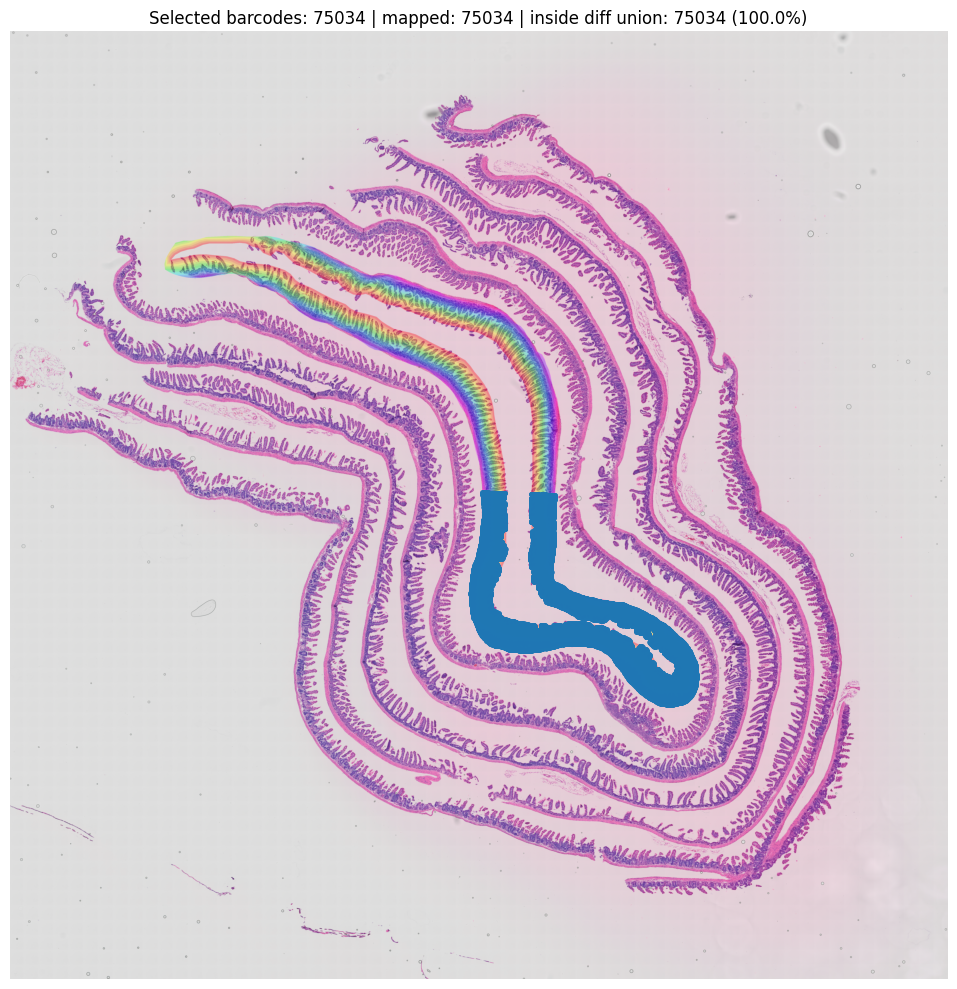

{'n_selected_barcodes_in_csv': 75034, 'n_selected_mapped_to_image': 75034, 'n_selected_inside_union_diff': 75034, 'fraction_inside_union_diff': 1.0}


In [60]:
# Cell 12
import os, glob, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib import cm

def _natural_key(path):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", os.path.basename(path))]

def overlay_diff_masks_rainbow_with_union(
    diff_dir,
    diff_glob="inflated_diff_*.png",
    base_img=None,
    alpha=0.35,
    cmap_name="hsv",
):
    diff_paths = sorted(glob.glob(os.path.join(diff_dir, diff_glob)), key=_natural_key)
    if not diff_paths:
        raise FileNotFoundError(f"No diff masks found with {os.path.join(diff_dir, diff_glob)}")

    first = np.array(Image.open(diff_paths[0]))
    if first.ndim == 3:
        first = first[..., 0]
    H, W = first.shape[:2]

    if base_img is None:
        comp = np.zeros((H, W, 3), dtype=np.float32)
    else:
        b = np.asarray(base_img)
        if b.shape[0] != H or b.shape[1] != W:
            raise ValueError(f"base_img shape {b.shape[:2]} does not match diff shape {(H,W)}")

        if b.ndim == 2:
            b = b.astype(np.float32)
            b = (b - b.min()) / (b.max() - b.min() + 1e-8)
            comp = np.repeat(b[..., None], 3, axis=2)
        elif b.ndim == 3 and b.shape[2] in (3, 4):
            b = b[..., :3].astype(np.float32)
            if b.max() > 1.5:
                b /= 255.0
            comp = np.clip(b, 0, 1)
        else:
            raise ValueError("base_img must be (H,W), (H,W,3), or (H,W,4)")

    cmap = cm.get_cmap(cmap_name, len(diff_paths))
    union_mask = np.zeros((H, W), dtype=bool)

    for i, p in enumerate(diff_paths):
        diff = np.array(Image.open(p))
        if diff.ndim == 3:
            diff = diff[..., 0]
        m = diff > 0
        union_mask |= m

        color = np.array(cmap(i)[:3], dtype=np.float32)
        comp[m] = (1 - alpha) * comp[m] + alpha * color

    return np.clip(comp, 0, 1), union_mask

def load_scalefactors_json(path_scalefactors_json):
    with open(path_scalefactors_json, "r") as f:
        return json.load(f)

def positions_xy_in_hires_pixels(tissue_positions_parquet, scalefactors_json, in_tissue_only=True):
    pos = pd.read_parquet(tissue_positions_parquet)
    sf = load_scalefactors_json(scalefactors_json)

    if in_tissue_only and "in_tissue" in pos.columns:
        pos = pos[pos["in_tissue"].astype(int) == 1].copy()

    needed = {"barcode", "pxl_row_in_fullres", "pxl_col_in_fullres"}
    if not needed.issubset(pos.columns):
        raise KeyError(f"Expected columns {needed} in tissue_positions parquet. Found: {list(pos.columns)}")

    s = float(sf["tissue_hires_scalef"])
    x = pos["pxl_col_in_fullres"].to_numpy() * s
    y = pos["pxl_row_in_fullres"].to_numpy() * s
    return pd.DataFrame({"barcode": pos["barcode"].astype(str).to_numpy(), "x": x, "y": y})

def qc_plot_roi_selection(
    img,
    diff_dir,
    barcode_to_ring_csv,
    tissue_positions_parquet,
    scalefactors_json,
    diff_glob="inflated_diff_*.png",
    alpha_masks=0.35,
    cmap_name="hsv",
    point_size=6,
    point_alpha=0.85,
):
    comp, union_mask = overlay_diff_masks_rainbow_with_union(
        diff_dir=diff_dir,
        diff_glob=diff_glob,
        base_img=img,
        alpha=alpha_masks,
        cmap_name=cmap_name,
    )
    H, W = union_mask.shape[:2]

    sel = pd.read_csv(barcode_to_ring_csv)
    sel_barcodes = sel["barcode"].astype(str).tolist()

    xy = positions_xy_in_hires_pixels(tissue_positions_parquet, scalefactors_json, in_tissue_only=True)
    xy_sel = xy[xy["barcode"].isin(sel_barcodes)].copy()

    xi = np.round(xy_sel["x"].to_numpy()).astype(int)
    yi = np.round(xy_sel["y"].to_numpy()).astype(int)

    inb = (xi >= 0) & (xi < W) & (yi >= 0) & (yi < H)
    xi = xi[inb]
    yi = yi[inb]
    xy_sel = xy_sel.loc[inb].reset_index(drop=True)

    hits = union_mask[yi, xi]
    frac_inside = float(hits.mean()) if len(hits) else 0.0

    plt.figure(figsize=(10, 10))
    plt.imshow(comp)
    plt.scatter(xy_sel["x"], xy_sel["y"], s=point_size, alpha=point_alpha)
    plt.axis("off")
    plt.title(
        f"Selected barcodes: {len(sel_barcodes)} | mapped: {len(xy_sel)} | inside diff union: {int(hits.sum())} ({frac_inside*100:.1f}%)",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

    return {
        "n_selected_barcodes_in_csv": len(sel_barcodes),
        "n_selected_mapped_to_image": len(xy_sel),
        "n_selected_inside_union_diff": int(hits.sum()) if len(hits) else 0,
        "fraction_inside_union_diff": frac_inside,
    }

diff_dir = str(ITER_DIR)
barcode_to_ring_csv = os.path.join(diff_dir, "barcode_to_ring.csv")

stats = qc_plot_roi_selection(
    img=img,
    diff_dir=diff_dir,
    barcode_to_ring_csv=barcode_to_ring_csv,
    tissue_positions_parquet=str(TISSUE_POSITIONS),
    scalefactors_json=str(SCALEFACTORS_JSON),
)
print(stats)


In [61]:
# Cell 13
import os
import pandas as pd
import scipy.sparse as sp

out_dir = os.path.join(str(ITER_DIR), "ring_subset_bin_by_gene")

X = sp.load_npz(os.path.join(out_dir, "counts_genes_by_bins.npz"))  # genes x bins
barcodes = pd.read_csv(os.path.join(out_dir, "barcodes.tsv"), header=None, sep="\t")[0].astype(str).tolist()
features = pd.read_csv(os.path.join(out_dir, "features.tsv"), sep="\t")
genes = features["feature_name"].astype(str).tolist()

ring_map = pd.read_csv(os.path.join(out_dir, "barcode_to_ring_aligned.csv"))  # columns: barcode, ring
assert ring_map["barcode"].astype(str).tolist() == barcodes

X_bins_by_genes = X.T.tocsr()  # bins x genes

df = pd.DataFrame.sparse.from_spmatrix(
    X_bins_by_genes,
    index=barcodes,
    columns=genes,
)

df.insert(0, "ring_id", ring_map["ring"].to_numpy())
df.index.name = "barcode"

df.head()


,ring_id,Xkr4,Rp1,Sox17,Lypla1,Tcea1,Rgs20,Atp6v1h,Oprk1,Npbwr1,...,mt-Atp8,mt-Atp6,mt-Co3,mt-Nd3,mt-Nd4l,mt-Nd4,mt-Nd5,mt-Nd6,mt-Cytb,Vamp7
barcode,,,,,,,,,,,,,,,,,,,,,
s_008um_00407_00594-1,1,0,0,0,0,0,0,0,0,0,...,0,3.0,0,0,0,0,0,0,4.0,0
s_008um_00571_00326-1,1,0,0,0,0,0,0,1.0,0,0,...,0,1.0,1.0,0,1.0,0,0,0,1.0,0
s_008um_00571_00327-1,1,0,0,0,0,0,0,1.0,0,0,...,0,2.0,6.0,0,0,0,0,0,6.0,0
s_008um_00571_00328-1,1,0,0,0,2.0,0,0,0,0,0,...,0,1.0,0,0,1.0,0,0,0,1.0,0
s_008um_00571_00329-1,1,0,0,0,1.0,0,0,0,0,0,...,2.0,0,11.0,0,0,1.0,1.0,0,3.0,0


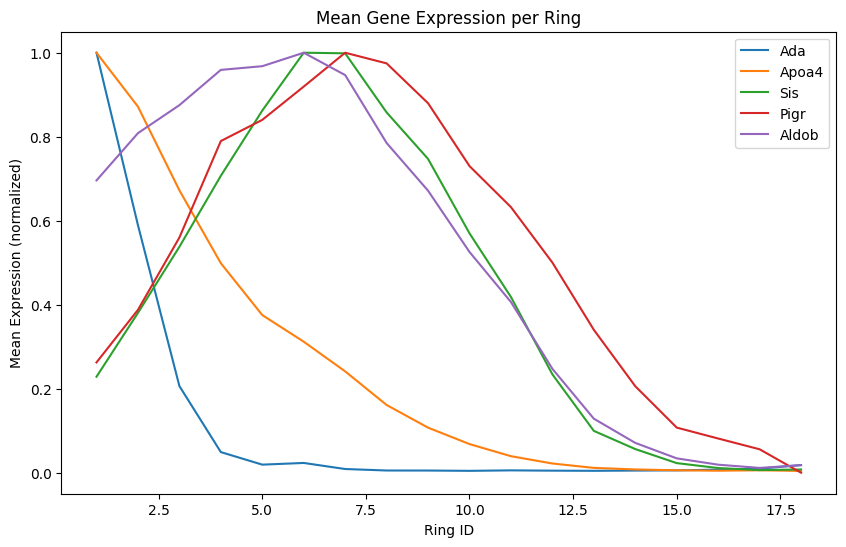

In [62]:
# Cell 14
# This cell takes the bin-by-gene df and calculates mean expression per ring, then plots selected genes
import matplotlib.pyplot as plt
import os

grouped = df.groupby("ring_id")
mean_expression = grouped.mean()
mean_expression.to_csv(os.path.join(out_dir, "mean_expression_per_ring.csv"))

selected_genes = ["Ada", "Apoa4", "Sis", "Pigr", "Aldob"]  # replace with your genes of interest

plt.figure(figsize=(10, 6))
for gene in selected_genes:
    if gene in mean_expression.columns:
        plt.plot(mean_expression.index, mean_expression[gene] / (mean_expression[gene].max() + 1e-8), label=gene)
    else:
        print(f"Warning: {gene} not found in expression data.")
plt.xlabel("Ring ID")
plt.ylabel("Mean Expression (normalized)")
plt.title("Mean Gene Expression per Ring")
plt.legend()
plt.savefig(os.path.join(out_dir, "mean_expression_per_ring.png"))
plt.show()
